## Necessary libraries

In [91]:
# ==== Data Analysis ====
import numpy as np
import pandas as pd
from IPython.display import display

# ==== Data Visualization ====
import matplotlib.pyplot as plt
import seaborn as sns

# ==== Configurations ====
import warnings
warnings.filterwarnings('ignore')


## Load data

In [34]:
df = pd.read_csv("../data/Medical Cost Personal Dataset - Regression.csv")

In [3]:
df.shape

(1338, 7)

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

## Basic feature descriptions: Numerical + Categorical

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## Data info

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

__No null values detected__

## Duplicate data detection

In [17]:
df.duplicated().sum()

1

__There is 1 duplicate record__

In [35]:
display(df[df.duplicated(keep='last')])

display(df[df.duplicated(keep='first')])

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


__We can consider either of the one, so we are dropping 1 record by keeping the first occurence.__

In [36]:
df = df.drop_duplicates(keep='first')

In [37]:
df.duplicated().sum()

0

__No duplicates detected.__

## Datatype Analysis

In [47]:
for col in df.columns:
    print(f"{col}:{df[col].dtype}")

age:int64
sex:object
bmi:float64
children:int64
smoker:object
region:object
charges:float64


__All the features have valid datatypes.__

## Numerical Features Exploration(uni-variate + multi-variate)
__Features:__ age, bmi, children, charges

__numerical_analysis(data, variable)__<br>User defined function which will help us to plot 2 different charts(histogram & boxplot) for the numerical features.

In [138]:
def numerical_analysis(data, variable):
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))

    sns.histplot(data[variable], kde=True, ax=ax[0], color="#0066ff")
    ax[0].set_xlabel(f"{variable.title()}")
    ax[0].set_ylabel("Frequency")
    
    sns.boxplot(x=data[variable], ax=ax[1], color="#4dff4d")
    ax[1].set_xlabel(f"{variable.title()}")

    fig.suptitle(f"{variable.upper()} distribution", )
    plt.tight_layout()

    plt.show()


## Age

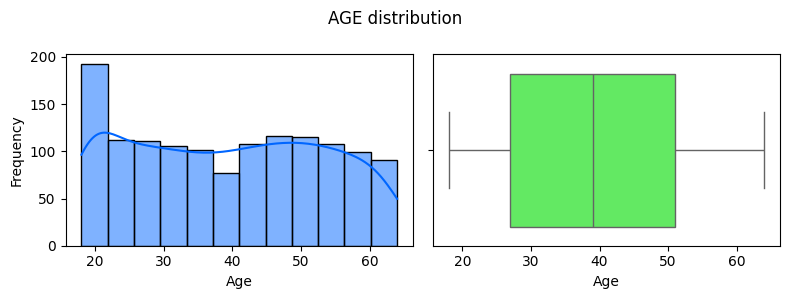

In [139]:
numerical_analysis(df, "age")

__Insights from the charts:__

- __Right-skewed with a young peak:__ Highest frequency is around age 20, then it gradually declines with a small secondary bump around 45-55.
- __Spread:__ Ages range from 18 to 64.
- __Boxplot:__ Median is 39, middle 50% of people are between ∼28 and ∼52, and the distribution is fairly symmetric in the center despite the skew at the young end.
- __No extreme outliers:__ Whiskers extend to the min/max, so ages ∼18 and ∼65 aren't flagged as outliers.

The data shows a young-skewed age distribution peaking near 20, with a median around 39 and most people between 28–52 years old.

## Insurance Charges by Age and Number of Children

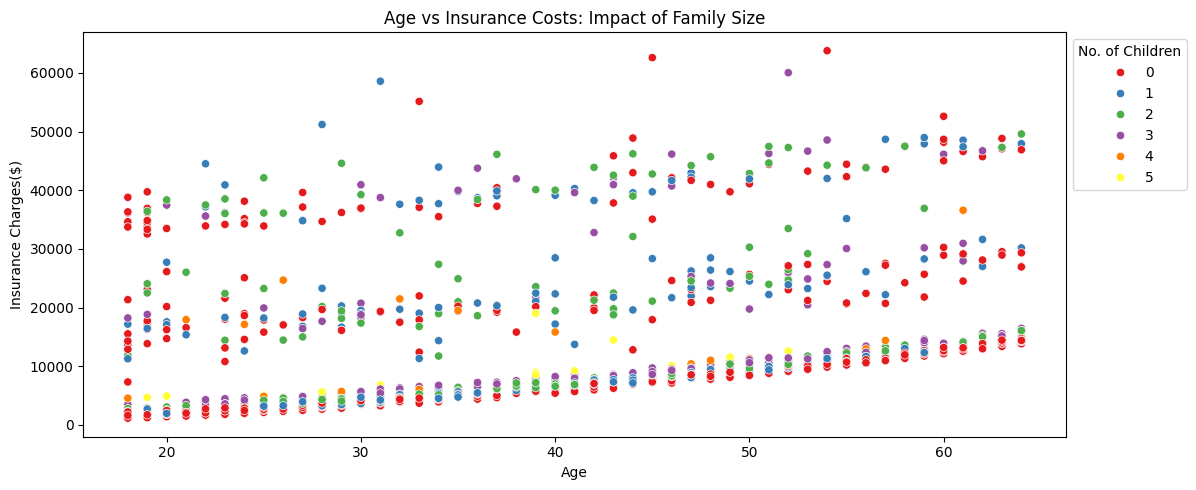

In [209]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x = "age", y = "charges", hue="children", palette = "Set1")

plt.xlabel("Age")
plt.ylabel("Insurance Charges($)")
plt.title("Age vs Insurance Costs: Impact of Family Size")
plt.legend(title = "No. of Children", ncol=1, bbox_to_anchor=(1.13, 1))
plt.tight_layout()

__Insights from the Age vs Charges scatter plot:__

- __Positive trend with age:__ Charges generally increase as age increases. The baseline cost rises from ∼2k at age 18 to ∼15k at age 64.
- __Three distinct bands:__ Data forms 3 horizontal clusters at different charge levels.
- __Number of children has weak impact:__ All colors appear in every band. Having more children doesn't drastically shift you to a higher band, but there’s a slight uptick, more kids = marginally higher charges within each band.
- __High variance after age 30:__ Spread gets wider with age. Some 45+ year olds pay 60k+, while others of the same age pay under 10k.

Charges rise with age and fall into three distinct cost tiers, with number of children having only a minor effect on the overall amount.

## Insurance Charges by Age and Smoker

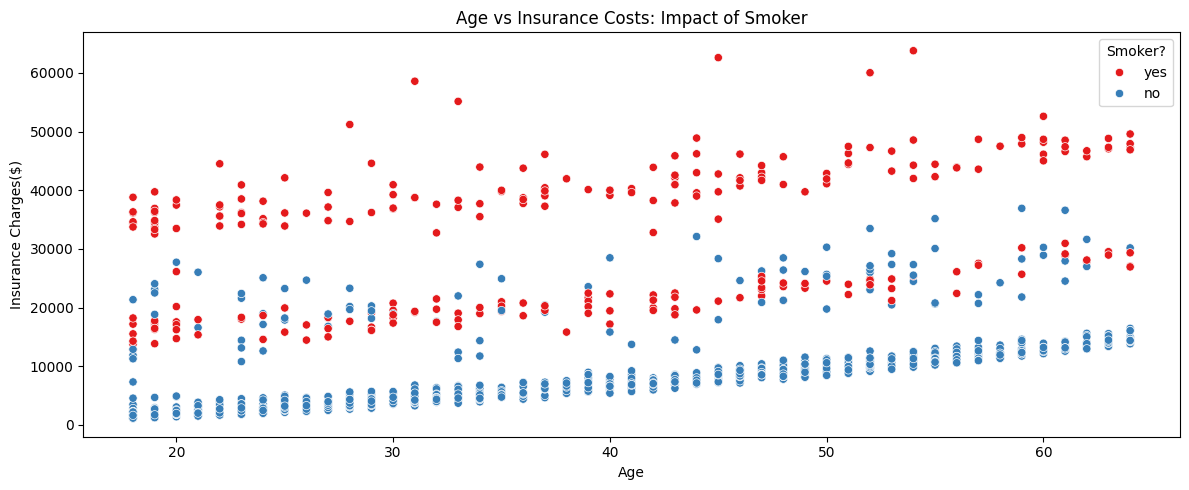

In [213]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x = "age", y = "charges", hue="smoker", palette = "Set1")

plt.xlabel("Age")
plt.ylabel("Insurance Charges($)")
plt.title("Age vs Insurance Costs: Impact of Smoker")
plt.legend(title = "Smoker?", ncol=1, bbox_to_anchor=(1, 1))
plt.tight_layout()

__Insights from the Age vs Insurance Costs: Impact of Smoker plot:__

- __Smoker status is the dominant driver:__ This explains the 3 bands. Smokers = red dots in the top 2 tiers, 30k–65k. Non-smokers = blue dots mostly under 20k.
- __Age still matters for both groups:__ Even among non-smokers, charges rise steadily from ∼2k at age 18 to ∼16k at age 64. For smokers, the baseline also trends upward with age.
- __Smoking creates a massive cost jump:__ At any given age, smokers pay ∼3–4x more than non-smokers. A 25-year-old smoker pays ∼35k while a 25-year-old non-smoker pays ∼5k.
- __Clear separation, but some overlap:__ A few smokers in their 20s–30s fall into the 15k–25k range, likely low-BMI smokers. A few non-smokers cross 30k, likely high-BMI or other risk factors.

Smoking is the strongest predictor of insurance cost, creating a 3–4x price gap at every age, with costs rising steadily for both smokers and non-smokers as they get older.

## BMI

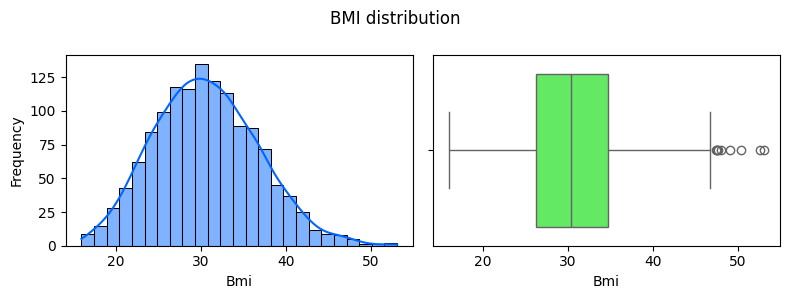

In [140]:
numerical_analysis(df, "bmi")

__Insights from the charts:__

- __Nearly normal distribution:__ Peaks around 30-31, with a slight right skew.
- __Central tendency:__ Median is ∼30, and the middle 50% fall between ∼26 and ∼35.
- __High-BMI outliers:__ Several points above ∼47 are marked as outliers on the boxplot.
- __Range:__ Most values are between 18 and 45, with the bulk concentrated in the 25–35 range.

BMI is roughly normally distributed around 30, with most values between 26–35 and a few high outliers above 47.

## Insurance Charges by BMI and Smoker

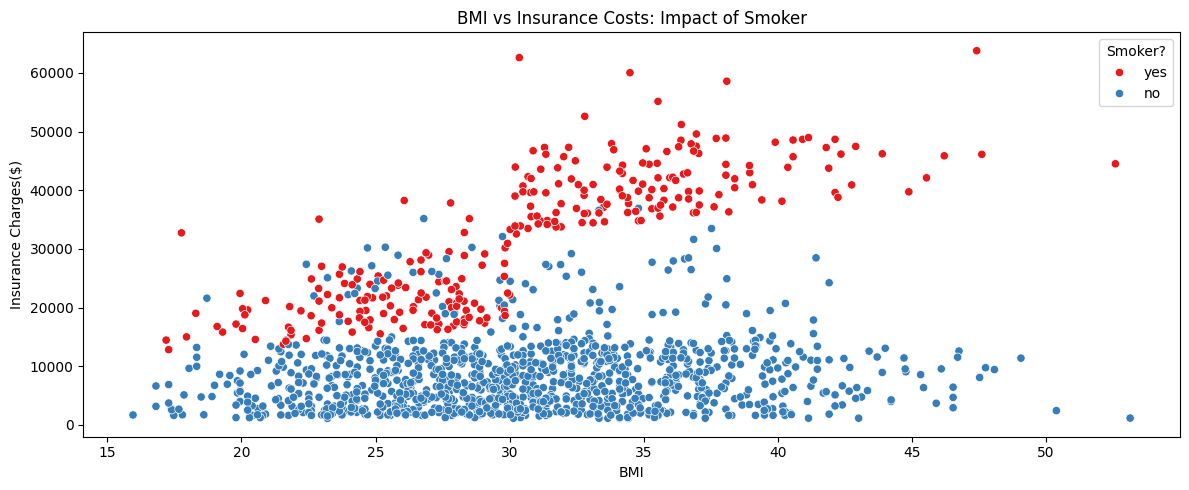

In [212]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x = "bmi", y = "charges", hue="smoker", palette = "Set1")

plt.xlabel("BMI")
plt.ylabel("Insurance Charges($)")
plt.title("BMI vs Insurance Costs: Impact of Smoker")
plt.legend(title = "Smoker?", ncol=1, bbox_to_anchor=(1, 1))
plt.tight_layout()

__Insights from the BMI vs Insurance Costs: Impact of Smoker plot:__

- __Smoker + high BMI = extreme costs:__ The red cluster above 30 BMI and 35k+ charges shows the interaction effect. Smokers with BMI > 30 pay dramatically more than any other group.
- __Non-smokers are unaffected by BMI:__ Blue dots stay under 20k across the entire BMI range. Even at BMI 50+, non-smokers still pay under 15k. BMI alone barely moves the needle.
- __Clear threshold at BMI 30 for smokers:__ Below BMI 30, smokers range 15k–35k. Above BMI 30, most smokers jump to 35k–65k. This is the obesity penalty that only applies to smokers.
- __Complete separation above BMI 30:__ After BMI 30, there’s almost no overlap. Red dots cluster 35k–65k, blue dots cluster 0–15k. Smoker status determines your cost tier.

BMI only drives up insurance costs for smokers, creating a massive price jump above BMI 30, while non-smokers remain low-cost regardless of BMI.

## Children

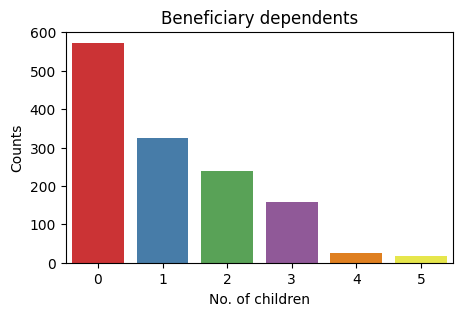

In [239]:
plt.figure(figsize=(5, 3))
sns.countplot(data = df, x = 'children', palette = "Set1")
plt.xlabel(f"No. of children")
plt.ylabel("Counts")
plt.title("Beneficiary dependents")
plt.show()

__Insights from the chart__

Most of the beneficiary have 0 children, then it gradually declines.

## Charges

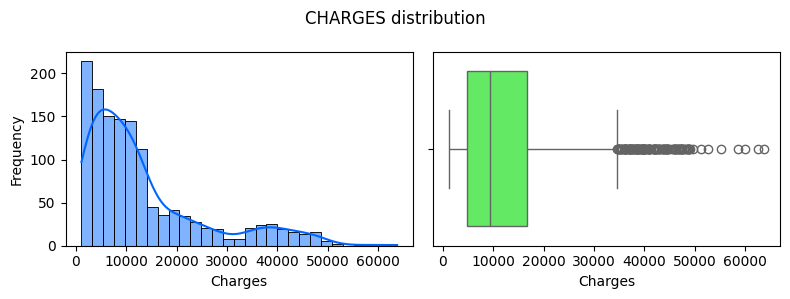

In [142]:
numerical_analysis(df, "charges")

__Insights from the CHARGES chart:__

- __Heavily right-skewed:__ Most charges are clustered at the low end, peaking around 0–10k.
- __Bimodal hint:__ Large peak near 5k–10k and a smaller secondary bump around 35k–45k.
- __Boxplot:__ Median is ∼10k, IQR spans ∼5k to ∼17k, but the long right whisker and many outliers show extreme high-cost cases.
- __Lots of high outliers:__ Charges above ∼35k are common, with some going beyond 60k.

Charges are highly right-skewed with most values under 15k, a median around 10k, and a long tail of high-cost outliers stretching past 60k.

## Categorical Features Exploration
__Features:__ sex, smoker, region

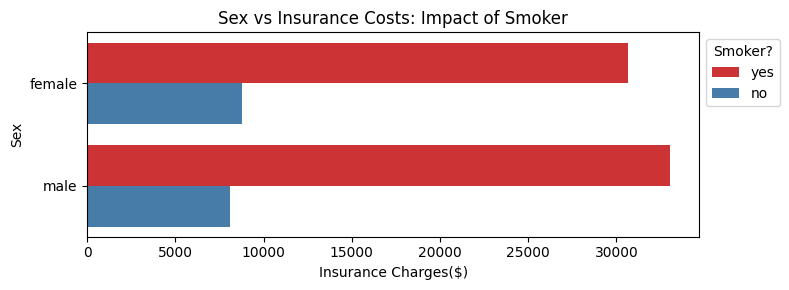

In [231]:
plt.figure(figsize=(8, 3))
sns.barplot(data=df, y = "sex", x = "charges", hue="smoker", palette = "Set1", errorbar=None)

plt.xlabel("Insurance Charges($)")
plt.ylabel("Sex")
plt.title("Sex vs Insurance Costs: Impact of Smoker")
plt.legend(title = "Smoker?", ncol=1, bbox_to_anchor=(1, 1))
plt.tight_layout()

__Insights from the Sex vs Insurance Costs: Impact of Smoker plot:__

- __Smoker status dominates sex:__ Within each sex, smokers pay ∼3.5x more than non-smokers. Smoking is still the main cost driver.
- __Males cost slightly more:__ Male smokers avg ∼33k vs female smokers ∼31k. Male non-smokers avg ∼8.5k vs female non-smokers ∼9k.
- __Sex effect is minor:__ The gap between male and female is only ∼2k for smokers and ∼0.5k for non-smokers. That’s small compared to the 20k+ gap between smoker and non-smoker.
- __Female non-smokers edge out male non-smokers:__ Interestingly, female non-smokers average slightly higher charges than male non-smokers, which could be due to age, BMI, or children differences in the data.

Insurance charges are driven primarily by smoking, with males costing slightly more than females and the smoker vs non-smoker gap dwarfing the sex difference. This bar chart confirms what the scatter plots showed: smoker is the key feature, and sex has minimal predictive power for insurance costs in this dataset.

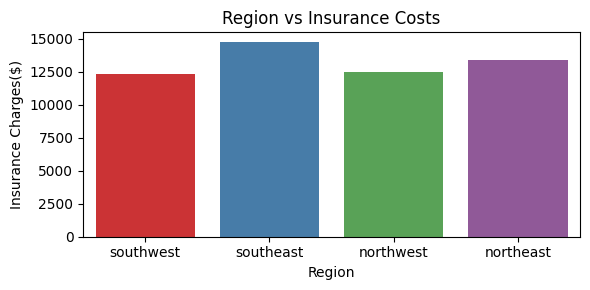

In [237]:
plt.figure(figsize=(6, 3))
sns.barplot(data=df, x = "region", y = "charges", palette = "Set1", errorbar=None)

plt.xlabel("Region")
plt.ylabel("Insurance Charges($)")
plt.title("Region vs Insurance Costs")
plt.tight_layout()

__Insights from the Region vs Insurance Costs plot:__

- __Southeast has the highest average:__ Southeast leads at ∼14.7k, about 2.3k higher than the lowest region.
- __Southwest and northwest are lowest:__ Both average ∼12.3k–12.5k.
- __Northeast sits in the middle:__ ∼13.4k, between southeast and the western regions.
- __Overall regional spread is small:__ The full range is only ∼2.4k, from ∼12.3k to ∼14.7k. That’s tiny compared to the 25k+ difference we saw between smokers and non-smokers.

Average insurance costs vary modestly by region, with the southeast highest at ∼14.7k and southwest/northwest lowest at ∼12.3k, but regional differences are small overall. Region explains way less variance than smoker, age, or BMI. It’s probably not a key feature for modeling charges in this dataset.

## Conclusion:

Features with little to no contribution
- __sex:__ The sex bar chart showed only ∼2k difference for smokers and ∼0.5k for non-smokers. Compared to the 25k+ gap from smoking, sex is noise. It adds almost no predictive power.
- __region:__ Regional averages only range from 12.3k to 14.7k. That’s a 2.4k spread total. Smoking alone causes a 20k+ jump. Region might reflect small lifestyle or cost-of-living differences, but it’s weak.
- __children:__ The Age vs Charges colored by children showed all colors in every cost band. Having more kids nudges costs up slightly within each band, but it never pushed someone into a different tier. Weak effect.

Features to keep and why

- __smoker:__ The single strongest predictor. Explains the 3 separate bands in Age vs Charges and the split clusters in BMI vs Charges. Causes 3–4x cost increase at every age.
- __age:__ Clear positive trend for both smokers and non-smokers. Baseline charges rise ∼14k from age 18 to 64.
- __bmi:__ Useless alone, non-smokers stay cheap at any BMI. But smoker = yes + BMI > 30 creates the 35k–65k cluster. You need the interaction.